# 🎓 AI Student Performance Prediction

Predicts whether a student will **Pass** or **Fail** based on study habits, attendance,
prior grades, and support factors, using and comparing three ML models:
Logistic Regression, Decision Tree, and Random Forest.

**Pipeline:** Data Generation/Loading → Preprocessing → EDA → Model Training → Evaluation → Prediction


In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", None)

import data_preprocessing

print(data_preprocessing.__file__)## 1. Load the Data
Using a synthetic dataset here — swap in your own CSV by editing `data/student_data.csv` (same column names) or updating `src/data_preprocessing.py`.

In [2]:
from data_preprocessing import load_raw_data

df = load_raw_data()
print(df.shape)
df.head()

(6607, 9)


,Hours_Studied,Attendance,Previous_Grade,Sleep_Hours,Parental_Support,Extracurricular,Internet_Access,Study_Group,Result
0,23,84,73,7,Low,No,Yes,0,Pass
1,19,64,59,8,Low,No,Yes,2,Fail
2,24,98,91,7,Medium,Yes,Yes,2,Pass
3,29,89,98,8,Low,Yes,Yes,1,Pass
4,19,92,65,6,Medium,Yes,Yes,3,Pass


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Hours_Studied     6607 non-null   int64
 1   Attendance        6607 non-null   int64
 2   Previous_Grade    6607 non-null   int64
 3   Sleep_Hours       6607 non-null   int64
 4   Parental_Support  6607 non-null   str  
 5   Extracurricular   6607 non-null   str  
 6   Internet_Access   6607 non-null   str  
 7   Study_Group       6607 non-null   int64
 8   Result            6607 non-null   str  
dtypes: int64(5), str(4)
memory usage: 464.7 KB


In [4]:
df.isna().sum()

Hours_Studied       0
Attendance          0
Previous_Grade      0
Sleep_Hours         0
Parental_Support    0
Extracurricular     0
Internet_Access     0
Study_Group         0
Result              0
dtype: int64

## 2. Exploratory Data Analysis

In [5]:
from visualization import run_all_eda
run_all_eda()

Saved 4 EDA figures to /home/claude/student_performance_prediction/outputs/figures


**Pass/Fail Balance**

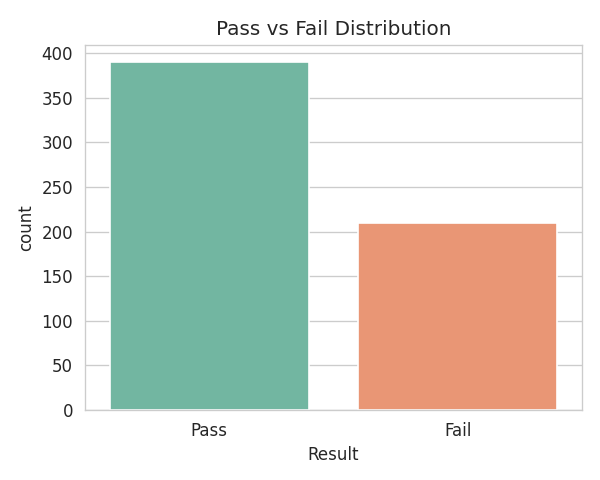

In [6]:
display(Image("../outputs/figures/target_balance.png"))

**Numeric Feature Distributions**

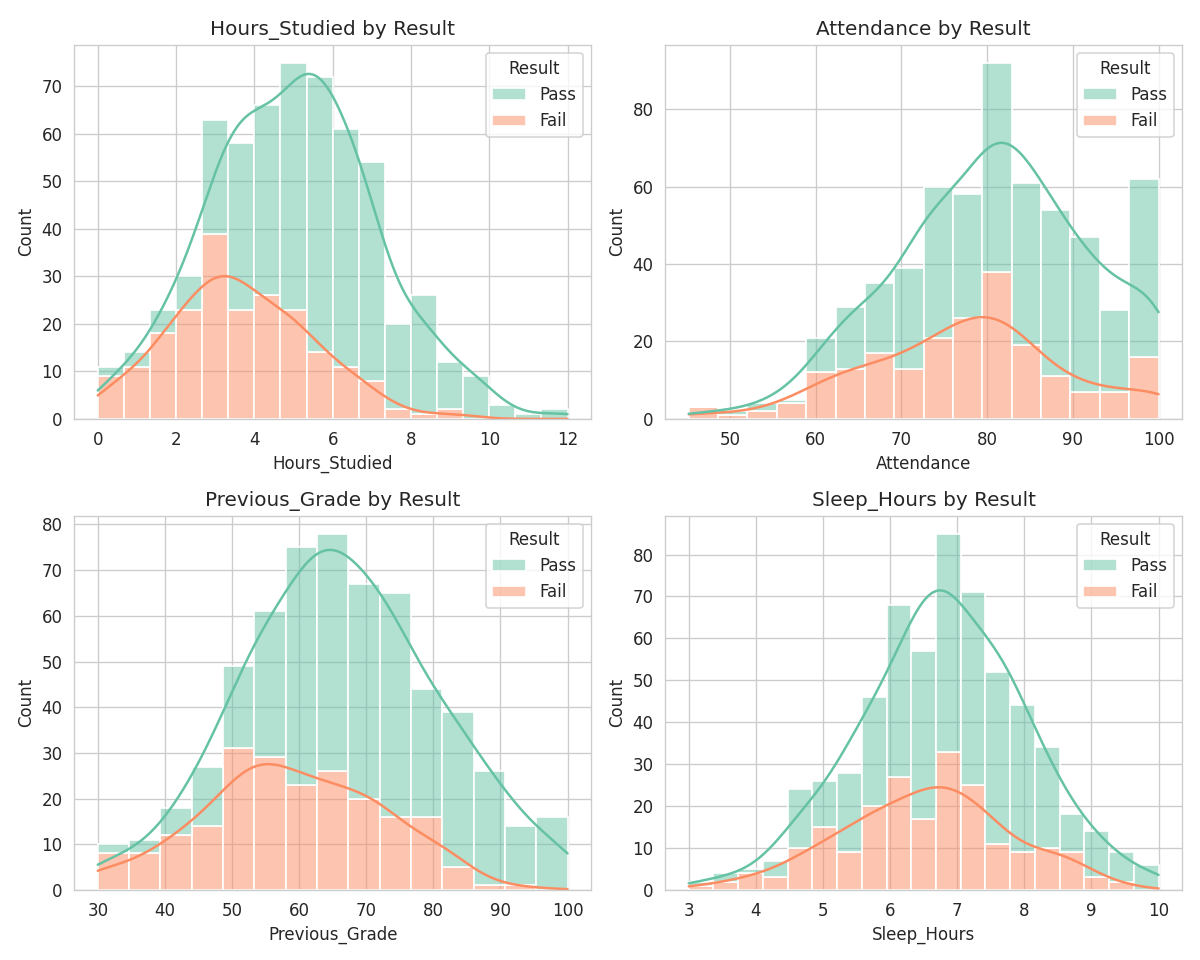

In [7]:
display(Image("../outputs/figures/numeric_distributions.png"))

**Correlation Heatmap**

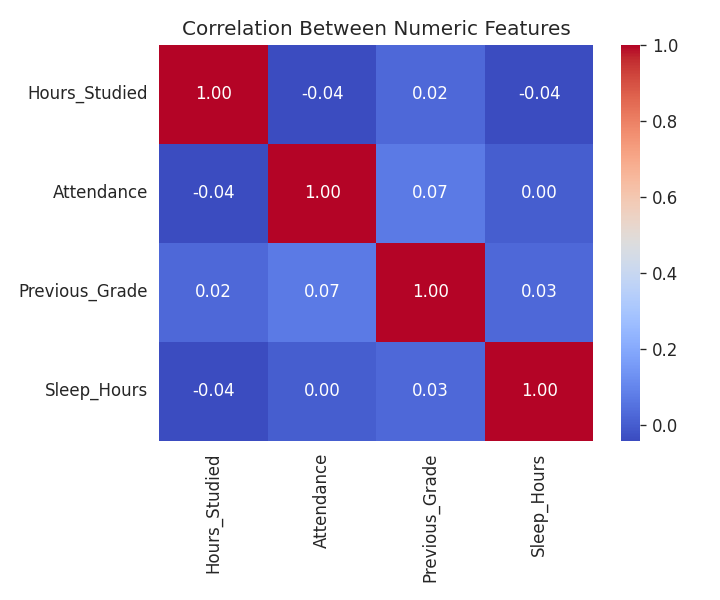

In [8]:
display(Image("../outputs/figures/correlation_heatmap.png"))

**Categorical Features vs Result**

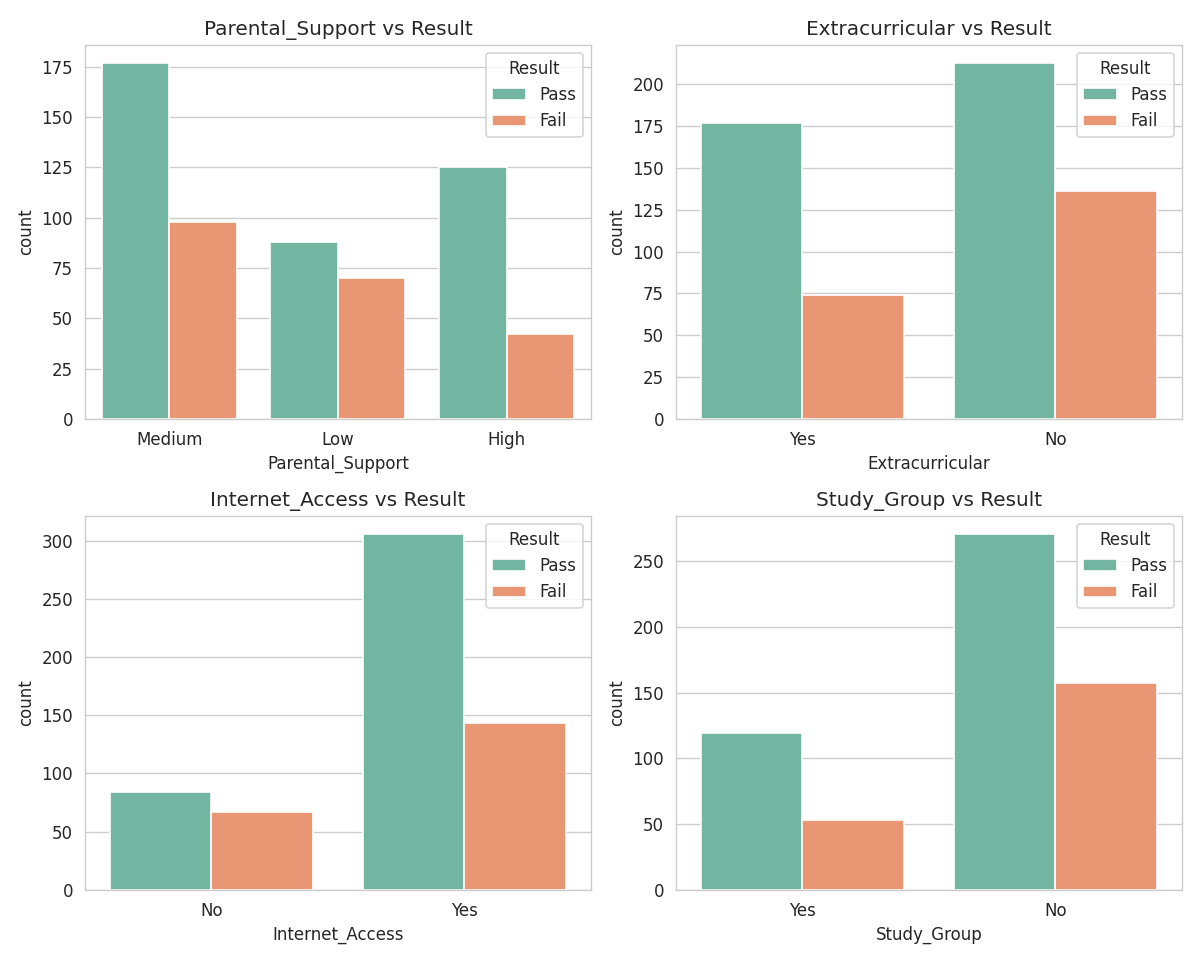

In [9]:
display(Image("../outputs/figures/categorical_vs_result.png"))

## 3. Preprocessing
Handles missing values, encodes categorical variables, splits train/test, and scales numeric features.

In [10]:
from data_preprocessing import load_and_prepare_data

X_train, X_test, y_train, y_test, scaler, encoders, feature_cols = load_and_prepare_data()
print("Train:", X_train.shape, " Test:", X_test.shape)
X_train.head()

Train: (5285, 8)  Test: (1322, 8)


,Hours_Studied,Attendance,Previous_Grade,Sleep_Hours,Parental_Support,Extracurricular,Internet_Access,Study_Group
6332,-0.492195,-0.513280,-1.743686,1.337410,-0.248487,-1.211330,0.283435,-1.220995
2302,-0.324177,1.572866,-0.704459,-0.024087,-0.248487,0.825539,0.283435,-0.406844
1287,0.515911,-1.469430,-0.427332,0.656661,0.904502,-1.211330,0.283435,0.407306
2164,1.524017,0.877484,0.057641,-0.024087,-1.401476,0.825539,0.283435,-0.406844
5644,0.851946,0.269025,0.889023,0.656661,-0.248487,0.825539,0.283435,-0.406844


In [11]:
print(y_train.unique())
print(y_test.unique())

[0 1]
[0 1]


print(df["Result"].unique())
print(df["Result"].value_counts(dropna=False))print(df["Result"].unique())
print(df["Result"].value_counts(dropna=False))## 4. Train & Compare Models
Trains Logistic Regression, Decision Tree, and Random Forest, then selects the best performer.

In [12]:
from train_models import main as train_main

results_df, best_name, best_model = train_main()
results_df


--- Logistic Regression ---
              precision    recall  f1-score   support

        Fail       0.87      0.83      0.85       577
        Pass       0.87      0.90      0.89       745

    accuracy                           0.87      1322
   macro avg       0.87      0.87      0.87      1322
weighted avg       0.87      0.87      0.87      1322


--- Decision Tree ---
              precision    recall  f1-score   support

        Fail       0.82      0.76      0.79       577
        Pass       0.83      0.87      0.85       745

    accuracy                           0.82      1322
   macro avg       0.82      0.82      0.82      1322
weighted avg       0.82      0.82      0.82      1322


--- Random Forest ---
              precision    recall  f1-score   support

        Fail       0.86      0.79      0.82       577
        Pass       0.84      0.90      0.87       745

    accuracy                           0.85      1322
   macro avg       0.85      0.84      0.85      1322

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.869894,0.871595,0.902013,0.886544
1,Random Forest,0.852496,0.844612,0.904698,0.873623
2,Decision Tree,0.822239,0.825255,0.868456,0.846305


**Model Comparison Chart**

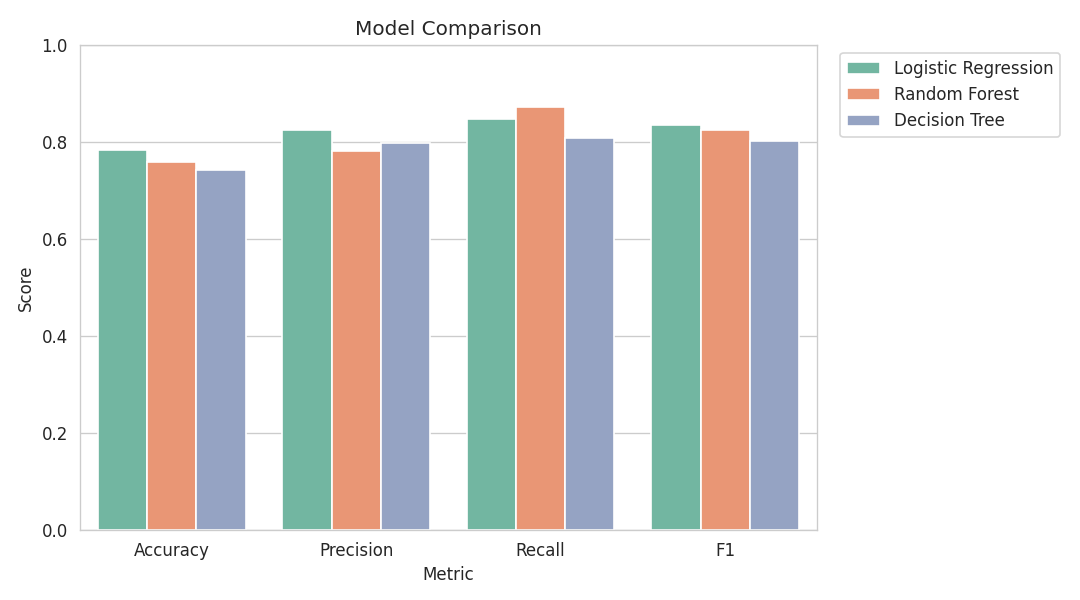

In [13]:
display(Image("../outputs/figures/model_comparison.png"))

**Confusion Matrices**

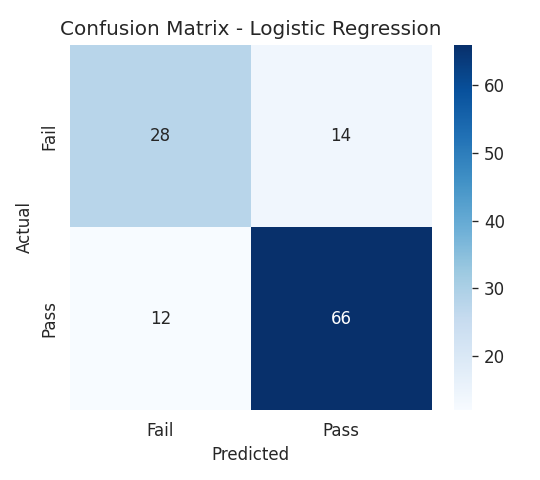

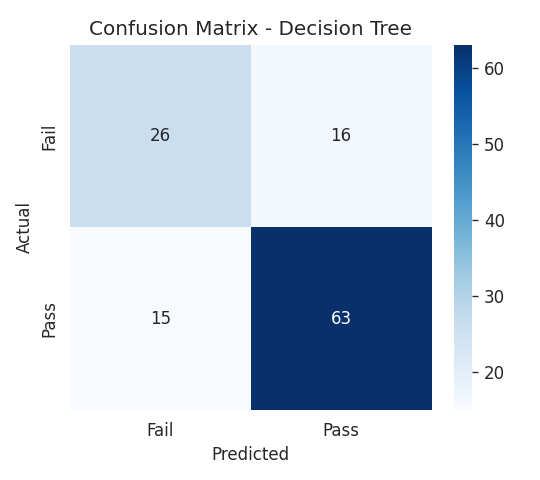

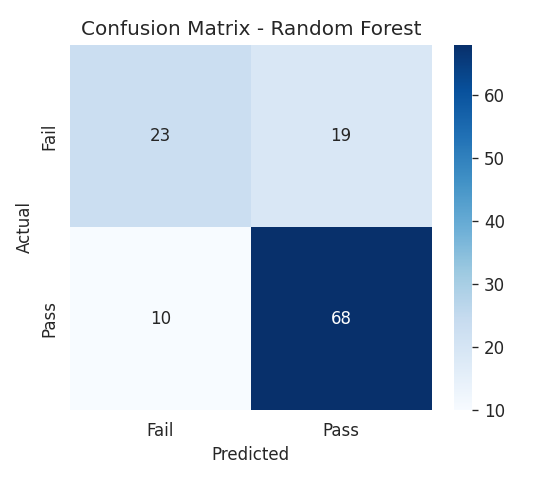

In [14]:
for name in ["logistic_regression", "decision_tree", "random_forest"]:
    display(Image(f"../outputs/figures/confusion_matrix_{name}.png"))

**Feature Importance (tree-based best model, if applicable)**

In [15]:
import os
path = "../outputs/figures/feature_importance.png"
if os.path.exists(path):
    display(Image(path))
else:
    print("Best model has no feature_importances_ (e.g. Logistic Regression) — see its coefficients instead.")

Best model has no feature_importances_ (e.g. Logistic Regression) — see its coefficients instead.


## 5. Predict a New Student
Loads the saved best model and predicts Pass/Fail for a new student profile.

In [ ]:
from predict import predict_student

new_student = {
    "Hours_Studied": 6.5,
    "Attendance": 88,
    "Previous_Grade": 72,
    "Sleep_Hours": 7,
    "Parental_Support": "High",
    "Extracurricular": "Yes",
    "Internet_Access": "Yes",
    "Study_Group": "No",
}

predict_student(new_student)

In [ ]:
print(df["Result"].value_counts())

In [ ]:
print(df["Result"].unique())
print(df["Result"].value_counts(dropna=False))

In [ ]:
import data_preprocessing

print(data_preprocessing.__file__)

In [ ]:
from data_preprocessing import load_raw_data

df = load_raw_data()

print(df["Result"].value_counts())

In [ ]:
print(df["Exam_Score"].describe())

In [ ]:
import pandas as pd

raw = pd.read_csv("data/student_data.csv")

print(raw["Exam_Score"].describe())

In [ ]:
df["Result"].value_counts()

In [ ]:
import pandas as pd

raw = pd.read_csv("data/student_data.csv")

print(raw.columns.tolist())
print()
print(raw["Exam_Score"].describe())

In [ ]:
from data_preprocessing import DATA_PATH
import pandas as pd

print(DATA_PATH)

raw = pd.read_csv(DATA_PATH)

print(raw.columns.tolist())
print()
print(raw["Exam_Score"].describe())

In [ ]:
from data_preprocessing import load_raw_data

df = load_raw_data()
print(df["Result"].value_counts())

In [ ]:
from data_preprocessing import load_raw_data

df = load_raw_data()
print(df["Result"].value_counts())

In [ ]:
from data_preprocessing import load_raw_data

df = load_raw_data()

print(df.head())
print(df["Result"].value_counts())

In [ ]:
from train_models import main as train_main

results_df, best_name, best_model = train_main()
results_df